In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
from geopy.distance import geodesic
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


In [2]:
# 计算弯曲度的函数
def calculate_sinuosity(latitudes, longitudes):
    # 计算路径的实际长度
    path_length = 0
    for i in range(1, len(latitudes)):
        point1 = (latitudes[i-1], longitudes[i-1])
        point2 = (latitudes[i], longitudes[i])
        path_length += geodesic(point1, point2).km
    
    # 计算起点和终点的直线距离
    start_point = (latitudes[0], longitudes[0])
    end_point = (latitudes[-1], longitudes[-1])
    straight_line_distance = geodesic(start_point, end_point).km
    
    # 计算弯曲度
    sinuosity = path_length / straight_line_distance
    return sinuosity

In [3]:
ds = xr.open_dataset('D:/data/GFDL/CMCC/CMCC-CM2-VHR4/TC-NH_TRACK_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_19500101-20141231.nc')

In [4]:
min_lon = 100
max_lon = 180
min_lat = 0
max_lat = 30

In [5]:
import pandas as pd
import numpy as np
import cftime

ressinuosity = []
resfrequency = []

for yearlis in range(1950, 2015):

    tracks_year = []

    # 遍历所有台风
    for i in range(ds.sizes['tracks']):
        # 获取轨迹的起始索引和轨迹数据
        start_index = ds['FIRST_PT'].isel(tracks=i).item()
        num_pts = ds['NUM_PTS'].isel(tracks=i).item()
        
        # 获取轨迹的时间和经纬度
        latitudes = ds['lat'].isel(record=slice(start_index, start_index + num_pts)).values
        longitudes = ds['lon'].isel(record=slice(start_index, start_index + num_pts)).values
        times = ds['time'].isel(record=slice(start_index, start_index + num_pts)).values

        # ✅ 自动识别 cftime 类型并转换为 pandas.Timestamp
        if isinstance(times[0], cftime.DatetimeNoLeap) or isinstance(times[0], cftime.Datetime360Day) or isinstance(times[0], cftime.DatetimeGregorian):
            times = [pd.Timestamp(t.strftime("%Y-%m-%d %H:%M:%S")) for t in times]
        else:
            times = pd.to_datetime(times)

        # 检查是否经过西北太平洋
        is_nw_pacific = False
        for lat, lon in zip(latitudes, longitudes):
            if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
                is_nw_pacific = True
                break  # 一旦发现经过西北太平洋，停止循环
        
        if is_nw_pacific:
            # 获取轨迹的第一个时间点和最后一个时间点
            first_time_dt = times[0]
            last_time_dt = times[-1]
            
            # 计算持续时间（小时）
            duration = (last_time_dt - first_time_dt).total_seconds() / 3600  
            
            # 获取风速数据（单位 m/s）
            wind_speeds = ds['sfcWind'].isel(record=slice(start_index, start_index + num_pts)).values  
            
            # 计算最大风速（单位：kt）
            max_wind_speed = np.max(wind_speeds) * 1.9438  
            
            # ✅ 筛选条件
            if first_time_dt.year == yearlis and 7 <= first_time_dt.month <= 10 and duration > 48 and max_wind_speed > 17.2:
                track_id = ds['TRACK_ID'].isel(tracks=i).item()
                track_data = ds.isel(record=slice(start_index, start_index + num_pts))
                
                tracks_year.append({
                    'track_id': track_id,
                    'start_time': first_time_dt,
                    'duration': duration,
                    'max_wind_speed': max_wind_speed,
                    'start_lat': latitudes[0],
                    'start_lon': longitudes[0],
                    'data': track_data
                })

    # 每年符合条件的台风数量
    resfrequency.append(len(tracks_year))

    # 计算弯曲度
    sinuosity_values = []
    for track in tracks_year:
        latitudes = track['data']['lat'].values
        longitudes = track['data']['lon'].values
        
        sinuosity = calculate_sinuosity(latitudes, longitudes)

        if sinuosity < 5:
            sinuosity_values.append(sinuosity)

    # 年平均弯曲度
    average_sinuosity = np.mean(sinuosity_values) if sinuosity_values else 0
    ressinuosity.append(average_sinuosity)

# ✅ 输出结果
for year, freq, sinu in zip(range(1982, 2015), resfrequency, ressinuosity):
    print(f"{year}年7-10月：符合条件的台风数={freq}，平均弯曲度={sinu:.3f}")


1982年7-10月：符合条件的台风数=27，平均弯曲度=1.827
1983年7-10月：符合条件的台风数=16，平均弯曲度=1.606
1984年7-10月：符合条件的台风数=16，平均弯曲度=1.580
1985年7-10月：符合条件的台风数=22，平均弯曲度=1.565
1986年7-10月：符合条件的台风数=37，平均弯曲度=1.770
1987年7-10月：符合条件的台风数=30，平均弯曲度=2.023
1988年7-10月：符合条件的台风数=26，平均弯曲度=1.762
1989年7-10月：符合条件的台风数=18，平均弯曲度=1.718
1990年7-10月：符合条件的台风数=20，平均弯曲度=1.908
1991年7-10月：符合条件的台风数=25，平均弯曲度=1.938
1992年7-10月：符合条件的台风数=22，平均弯曲度=1.783
1993年7-10月：符合条件的台风数=28，平均弯曲度=1.696
1994年7-10月：符合条件的台风数=18，平均弯曲度=1.826
1995年7-10月：符合条件的台风数=24，平均弯曲度=1.993
1996年7-10月：符合条件的台风数=21，平均弯曲度=1.749
1997年7-10月：符合条件的台风数=28，平均弯曲度=1.612
1998年7-10月：符合条件的台风数=27，平均弯曲度=1.718
1999年7-10月：符合条件的台风数=32，平均弯曲度=1.669
2000年7-10月：符合条件的台风数=28，平均弯曲度=1.950
2001年7-10月：符合条件的台风数=22，平均弯曲度=1.654
2002年7-10月：符合条件的台风数=25，平均弯曲度=1.471
2003年7-10月：符合条件的台风数=22，平均弯曲度=2.144
2004年7-10月：符合条件的台风数=30，平均弯曲度=1.775
2005年7-10月：符合条件的台风数=13，平均弯曲度=1.402
2006年7-10月：符合条件的台风数=30，平均弯曲度=1.851
2007年7-10月：符合条件的台风数=21，平均弯曲度=1.707
2008年7-10月：符合条件的台风数=14，平均弯曲度=1.662
2009年7-10月：符合条件的台风数=29，平均弯曲度=1.699
2010年7-10月：符合条件的台风数=

In [6]:
ressinuosity

[np.float64(1.827109267803046),
 np.float64(1.6055572686659378),
 np.float64(1.5796277717370093),
 np.float64(1.5650407103237212),
 np.float64(1.7701576913525854),
 np.float64(2.0228074153291993),
 np.float64(1.7621408970925425),
 np.float64(1.7178253494460813),
 np.float64(1.9084694116671503),
 np.float64(1.9383962305643785),
 np.float64(1.7829766376194947),
 np.float64(1.696291223488584),
 np.float64(1.8258609189544626),
 np.float64(1.9929663407866032),
 np.float64(1.7488474571441681),
 np.float64(1.6119452986793488),
 np.float64(1.7180112257619211),
 np.float64(1.6686473977367902),
 np.float64(1.949553358118078),
 np.float64(1.654442791334312),
 np.float64(1.471289605876273),
 np.float64(2.1440385220690827),
 np.float64(1.7751662439864637),
 np.float64(1.4022111199785694),
 np.float64(1.8505203926820697),
 np.float64(1.706700818460242),
 np.float64(1.6623463230192894),
 np.float64(1.6994957792557777),
 np.float64(1.6839978440520897),
 np.float64(1.6923183561708035),
 np.float64(1.70

In [7]:
resfrequency

[27,
 16,
 16,
 22,
 37,
 30,
 26,
 18,
 20,
 25,
 22,
 28,
 18,
 24,
 21,
 28,
 27,
 32,
 28,
 22,
 25,
 22,
 30,
 13,
 30,
 21,
 14,
 29,
 23,
 18,
 23,
 21,
 24,
 14,
 34,
 23,
 12,
 14,
 23,
 18,
 28,
 33,
 25,
 35,
 27,
 19,
 17,
 25,
 15,
 13,
 28,
 25,
 17,
 25,
 24,
 15,
 17,
 29,
 9,
 25,
 9,
 13,
 24,
 19,
 34]

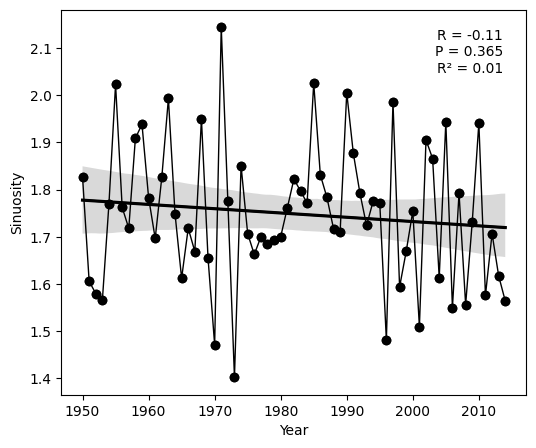

R: -0.11416055503485774
P: 0.365201424902594
R2: 0.013032632325866782


In [8]:
years = np.arange(1950, 2015)
x=years
y=ressinuosity
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
textstr = f"R = {r_value:.2f}\nP = {p_value:.3f}\nR² = {r_squared:.2f}"
ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        fontsize=10, va='top', ha='right')
plt.xlabel('Year')
plt.ylabel('Sinuosity')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

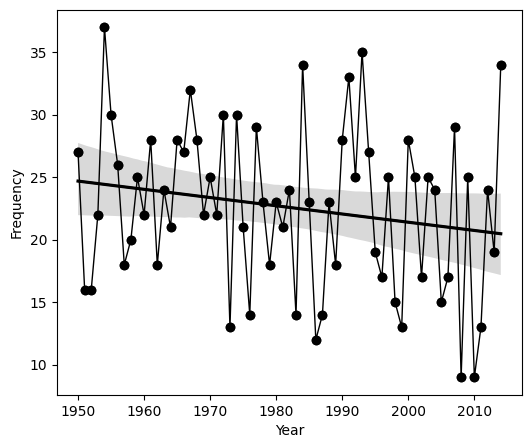

R: -0.1904906809851686
P: 0.12852581666198862
R2: 0.036286699542193275


In [10]:
years = np.arange(1950, 2015)
x=years
y=resfrequency
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)